In [3]:
areas = pd.read_csv("area_protegida.csv")

NameError: name 'pd' is not defined

1. carga y exploracion general

In [68]:
areas.head(5)

,lat,lng,gid,entidad,objeto,fna,gna,nam,tap,jap,caa,fdc,sag,area
0,-53.546655,-68.041297,362,falso,Área protegida,Sitio RAMSAR y Reserva Hemisférica Costa Atlán...,Sitio RAMSAR y Reserva Hemisférica,Costa Atlántica de Tierra del Fuego,2,2,17,SIB/IGN/Ley Provincial Nº 415/1998,IGN,762166
1,-31.404445,-64.357709,157,falso,Área protegida,Reserva Natural de la Defensa La Calera,Reserva Natural de la Defensa,La Calera,2,2,17,SIB/IGN/Protocolo adicional Nº 05/2009,IGN,136225
2,-32.245004,-60.734423,169,falso,Área protegida,Sitio Ramsar Delta del Parana,Sitio Ramsar,Delta del Parana,2,2,17,NaN,MAyDS,2430979
3,-26.031780,-54.418743,47,falso,Área protegida,Parque Natural Municipal Lote C Huerto Municipal,Parque Natural Municipal,Lote C Huerto Municipal,1,4,17,SIB/IGN/Disposición Nº 45/95,IGN,955
4,-26.402258,-65.680992,206,falso,Área protegida,Parque Provincial Cumbres Calchaquíes,Parque Provincial,Cumbres Calchaquíes,1,3,17,NaN,IGN,706222


viendo las primeras 5 columnas de Areas Protegidas, podemos notar como las primeras filas muestran los valores: de Latitud y Longitud para calcular y saber donde se ubican las zonas, luego la fila Gid con valores no decimales, Entidad hace referencia al objeto geografico, fna que muestra el nombre del sitio de la area protegida, luego esta Gna que muestra el nombre de la "provincia" donde se ubica. luego se muestra informaciona dicional donde Tap es el "tipo de area" y Jap es "Jurisdiccion". y de ultimo tenemos la fila Caa que muestra el tipo de certificacion

2. Estructura y tipos de datos

In [69]:
areas.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   lat      395 non-null    float64
 1   lng      395 non-null    float64
 2   gid      395 non-null    int64  
 3   entidad  395 non-null    str    
 4   objeto   395 non-null    str    
 5   fna      395 non-null    str    
 6   gna      395 non-null    str    
 7   nam      395 non-null    str    
 8   tap      395 non-null    int64  
 9   jap      395 non-null    int64  
 10  caa      395 non-null    int64  
 11  fdc      336 non-null    str    
 12  sag      394 non-null    str    
 13  area     395 non-null    int64  
dtypes: float64(2), int64(5), str(7)
memory usage: 43.3 KB


latencia y longitud son datos decimales para almacenar informacion no enteros,  

gid almacena numeros enteros

como entidad es el valor del tipo de geografia de la zona, esta marcada con strings que representan true y false

objeto es un string que muestra informacion sobre cual area esta protegida

fna es un string que muestra el nombre de la provincia donde se ubica el area protegida

gna es el string que indica cual es el tipo de objeto de la area restringida como ejemplo: establecimiento o rio

PARTE 2

In [70]:
areas.jap.value_counts()

jap
 3    222
 2    103
 5     33
 4     32
 0      3
-1      2
Name: count, dtype: int64

1. cuantos valores contados tendria jurisdiccion?

In [78]:
c1 = areas[(areas["jap"] == 2)&(areas["tap"] == 1)].shape[0]

c1

41

2. supongamos que queremos contar los valores de jurisdicción y tipo de área, donde sus tipos de datos son:


jurisdiccion es: reserva



tipo de area es: parque

In [46]:
g = areas[areas["area"] >= 20000000]
g["area"]

33     25855332
34     30740644
40     58234860
62     30553073
341    23573774
Name: area, dtype: int64

3. intentamos obtener la fila "gid" ya que es un valor numerico, limitamos sus valores a partir de ser mayor o igual a 20000000 y luego solo mostrar el resultado de dicha fila

In [21]:
import plotly.express as px

In [42]:
!pip install plotly

In [45]:
count = areas["jap"].value_counts()
grafico = px.pie(data_frame = count, values = count.values, names = count.index, title = "valores de juri")
grafico.show()

4.
aca deberia mostrar el grafico pero no lo hace pq este de codigo no quiere funcionar a pesar de ser correcto

entonces sabemos que jap muestra las jurisdiccion de las areas, hasta se podrian contar cada una de estas jurisdicciones, y visualizarlas para comparar cada una!

In [40]:
import plotly.express as px

In [49]:
nomb = areas[areas["gna"] == "Parque Natural Municipal"]
nomb

,lat,lng,gid,entidad,objeto,fna,gna,nam,tap,jap,caa,fdc,sag,area
3,-26.031780,-54.418743,47,falso,Área protegida,Parque Natural Municipal Lote C Huerto Municipal,Parque Natural Municipal,Lote C Huerto Municipal,1,4,17,SIB/IGN/Disposición Nº 45/95,IGN,955
28,-27.402324,-55.203168,102,falso,Área protegida,Parque Natural Municipal Paraje los Indios,Parque Natural Municipal,Paraje los Indios,1,4,17,NaN,MAyDS,206
86,-26.021745,-54.610589,54,falso,Área protegida,Parque Natural Municipal Yarará,Parque Natural Municipal,Yarará,1,4,17,SIB/IGN/Ordenaza Municipal Nº 24/1995,IGN,104
115,-34.468699,-58.494295,90,falso,Área protegida,Parque Natural Municipal Ribera Norte,Parque Natural Municipal,Ribera Norte,2,4,17,IGN/Portal Web de la Municipalidad,IGN,140
144,-25.594299,-54.576966,122,falso,Área protegida,Parque Natural Municipal Luis Honorio Rolón,Parque Natural Municipal,Luis Honorio Rolón,1,4,17,SIB/IGN/Ordenanza Municipal Nº 27-20/1996,IGN,134


5.
¿sabian que gna muestra parte del nombre geografico de las areas protegidas?
nos da la oportunidad de buscar las que necesitamos y identificarlas

In [52]:
nomb = areas[areas["nam"] == "Monte Loayza"]
nomb

,lat,lng,gid,entidad,objeto,fna,gna,nam,tap,jap,caa,fdc,sag,area
48,-47.082512,-66.326626,22,falso,Área protegida,Área de Uso Científico Monte Loayza,Área de Uso Científico,Monte Loayza,2,3,17,SIB/IGN/Disposición Provincial Nº 14/1989,IGN,124095
68,-47.088903,-66.332360,36,falso,Área protegida,Reserva Provincial Monte Loayza,Reserva Provincial,Monte Loayza,2,3,17,SIB/IGN/Ley Provincial Nº 2.828,IGN,76062


6.
entonces, si con el codigo anterior podemos llamar a los nombres geograficos de las areas, entonces tambien podria funcionar con los demas tipos de informacion que conforman estos tipos de nombres de areas geograficas! como ejemplo, identificar el nombre geografico individual de un objeto determinado

In [53]:
h = areas["sag"].head(5).value_counts()
px.bar(data_frame = h, x = h.values, y = h.index, title = "barra de sag").show()


7.
¿sabian que la informacion sag muestra el nombre de la autoridad responsable de la informacion utilizada?
eso me hace preguntar: ¿cual autoridad tiene mas informacion utilizada?

In [1]:
import folium as mapp

In [20]:
g = areas[areas["jap"] == 5]

mapa = mapp.Map(
    location=[g["lat"].mean(), g["lng"].mean()],
    zoom_start=4
)

for _, fila in g.iterrows():

    mapp.CircleMarker(
        location=[fila["lat"], fila["lng"]],
        radius=6,
        color=colors.get(fila["jap"], "cyan"),
        popup=fila["nam"]
    ).add_to(mapa)
mapa


8.
al importar folium, podriamos navegar en un mapa lo que nosotros le mandamos a los comandos a hacer.

seria interesante saber donde se ubican los lugares privados de jurisdiccion

In [4]:
import pandas as pd


In [5]:
areas = pd.read_csv("area_protegida.csv")

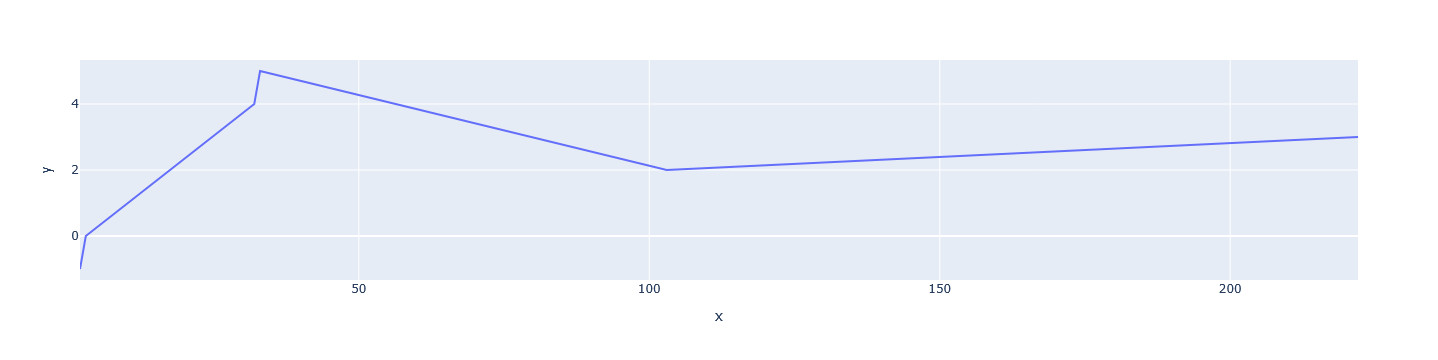

In [38]:
g = areas["jap"].value_counts()
px.line(data_frame = g, x = g.values, y = g.index, title = "").show()

como seria un grafico en linea donde se analiza la informacion de jurisdiccion? 

In [48]:
c1 = areas[(areas["jap"] != -1)&(areas["jap"] != 0)]
c1

,lat,lng,gid,entidad,objeto,fna,gna,nam,tap,jap,caa,fdc,sag,area
0,-53.546655,-68.041297,362,falso,Área protegida,Sitio RAMSAR y Reserva Hemisférica Costa Atlán...,Sitio RAMSAR y Reserva Hemisférica,Costa Atlántica de Tierra del Fuego,2,2,17,SIB/IGN/Ley Provincial Nº 415/1998,IGN,762166
1,-31.404445,-64.357709,157,falso,Área protegida,Reserva Natural de la Defensa La Calera,Reserva Natural de la Defensa,La Calera,2,2,17,SIB/IGN/Protocolo adicional Nº 05/2009,IGN,136225
2,-32.245004,-60.734423,169,falso,Área protegida,Sitio Ramsar Delta del Parana,Sitio Ramsar,Delta del Parana,2,2,17,NaN,MAyDS,2430979
3,-26.031780,-54.418743,47,falso,Área protegida,Parque Natural Municipal Lote C Huerto Municipal,Parque Natural Municipal,Lote C Huerto Municipal,1,4,17,SIB/IGN/Disposición Nº 45/95,IGN,955
4,-26.402258,-65.680992,206,falso,Área protegida,Parque Provincial Cumbres Calchaquíes,Parque Provincial,Cumbres Calchaquíes,1,3,17,NaN,IGN,706222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,-30.379778,-62.810767,387,falso,Área protegida,Sitios RAMSAR y Reserva Provincial de Uso Múlt...,Sitios RAMSAR y Reserva Provincial de Uso Múltipl,Bañados del Río Dulce y Laguna de Mar Chiquita,2,2,17,SIB/IGN/Decreto Provincial N° 3.215/1994,IGN,10726532
388,-30.705936,-62.597763,390,falso,Área protegida,Parque Nacional Ansenuza,Parque Nacional,Ansenuza,1,2,17,Ley 27673,IGN,1776194
390,-41.498783,-64.984633,389,falso,Área protegida,Parque Nacional Islote Lobos,Parque Nacional,Islotes Lobos,1,2,17,SIB/IGN/Decreto Provincial Nº 1.402/1977,IGN,195383
391,-27.180310,-58.690677,392,falso,Area Protegida,Parque Nacional Laguna El Palmar,Parque Nacional,Laguna El Palmar,1,2,17,Ley 27707,IGN,55535


9.
como podrias optener la informacion de jurisdiccion que esten disponibles?

In [56]:
g = areas[(areas["tap"] == 1)&(areas["jap"] == 4)]

mapa = mapp.Map(
    location=[g["lat"].mean(), g["lng"].mean()],
    zoom_start=4
)

for _, fila in g.iterrows():

    mapp.CircleMarker(
        location=[fila["lat"], fila["lng"]],
        radius=6,
        popup=fila["nam"]
    ).add_to(mapa)
mapa

10.
    queremos saber el mapa de los parques que cuenten como una area municipal